<a href="https://colab.research.google.com/github/magdoch/ML_python_projects/blob/main/HW_2_3_%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%B0_%D0%BF%D1%80%D0%B8%D0%B9%D0%BD%D1%8F%D1%82%D1%82%D1%8F_%D1%80%D1%96%D1%88%D0%B5%D0%BD%D1%8C_%D0%A1%D0%BE%D1%80%D0%BE%D0%BA%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
import os
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [2]:
!pip install opendatasets --quiet


In [3]:
import opendatasets as od
import os


In [4]:
!pip -q install -U ipython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 622.8/622.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 2.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.10.0 which is incompatible.


In [7]:
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-4/data'

In [8]:
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: mariiasoroka04
Your Kaggle Key: ··········


100%|██████████| 637k/637k [00:00<00:00, 462MB/s]


Extracting archive ./bank-customer-churn-prediction-dlu-course-c-4/bank-customer-churn-prediction-dlu-course-c-4.zip to ./bank-customer-churn-prediction-dlu-course-c-4


In [9]:
%load_ext autoreload
%autoreload 2


In [10]:
from process_bank_churn import preprocess_data, preprocess_new_data

In [11]:
raw_df= pd.read_csv('./bank-customer-churn-prediction-dlu-course-c-4/train.csv')

In [13]:
data = preprocess_data(raw_df)

In [14]:
X_train = data['train_X']
train_targets = data['train_y']
X_val = data['val_X']
val_targets = data['val_y']


In [15]:
data = preprocess_data(raw_df, scaler_numeric=False)

X_train = data["train_X"]
train_targets = data["train_y"]

X_val = data["val_X"]
val_targets = data["val_y"]

# test робимо через preprocess_new_data
X_test = preprocess_new_data(
    data["test_raw_X"],
    input_cols=data["input_cols"],
    scaler=data["scaler"],
    encoder=data["encoder"],
    scaler_numeric=False,
    raw_input_cols=data["meta"]["raw_input_cols"],
    drop_cols=data["meta"]["drop_cols"],
)

test_targets = data["test_y"]

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [16]:
from sklearn.tree import DecisionTreeClassifier

In [17]:
model = DecisionTreeClassifier(random_state=42)

In [18]:
%%time
model.fit(X_train, train_targets)

CPU times: user 52 ms, sys: 0 ns, total: 52 ms
Wall time: 52.1 ms


DecisionTreeClassifier(random_state=42)

In [19]:
from sklearn.metrics import roc_auc_score

train_probs = model.predict_proba(X_train)[:, 1]
test_probs = model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(train_targets, train_probs)
test_auc = roc_auc_score(test_targets, test_probs)

print("Train ROC AUC:", train_auc)
print("Test ROC AUC:", test_auc)

Train ROC AUC: 1.0
Test ROC AUC: 0.7840592633239591


Можем побачита, що наша модель є перенавчена, бо на тренувальніх даних наш ROC по-перше становить 1, що само по собі вже викликає підозри, а по-друге на тестувальних даних якісь на 22% менша.

In [20]:
model.tree_.max_depth

20

глибина дерева становить 20.

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [22]:
train_preds = model.predict(X_train)

In [23]:
train_preds

array([0., 0., 1., ..., 1., 1., 0.])

In [24]:
pd.value_counts(train_preds)

/tmp/ipython-input-158/1258350197.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(train_preds)


,count
0.0,7169
1.0,1831


In [25]:
train_probs = model.predict_proba(X_train)

In [26]:
train_probs[:10]

array([[1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [27]:
accuracy_score(train_targets, train_preds)

1.0

In [28]:
model.score(X_val, val_targets)

0.846

In [29]:
val_targets.value_counts() / len(val_targets)

,count
Exited,
0.0,0.796333
1.0,0.203667


In [30]:
from sklearn.tree import plot_tree, export_text

[Text(0.5, 0.875, 'Age <= 43.5\ngini = 0.324\nsamples = 9000\nvalue = [7169, 1831]'),
 Text(0.25, 0.625, 'NumOfProducts <= 1.5\ngini = 0.191\nsamples = 7250\nvalue = [6476, 774]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Age <= 39.5\ngini = 0.341\nsamples = 2741\nvalue = [2143, 598]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'NumOfProducts <= 2.5\ngini = 0.075\nsamples = 4509\nvalue = [4333, 176]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'NumOfProducts <= 1.5\ngini = 0.478\nsamples = 1750\nvalue = [693, 1057]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'IsActiveMember <= 0.5\ngini = 0.346\nsamples = 1124\nvalue = [250, 874]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'NumOfProducts <= 2.5\ngini = 0.414\nsamples = 626\nvalue = [443, 183]'),
 Text(0.8125, 0.125, '\n  (...)  \n'),
 Text(0.9375, 0.1

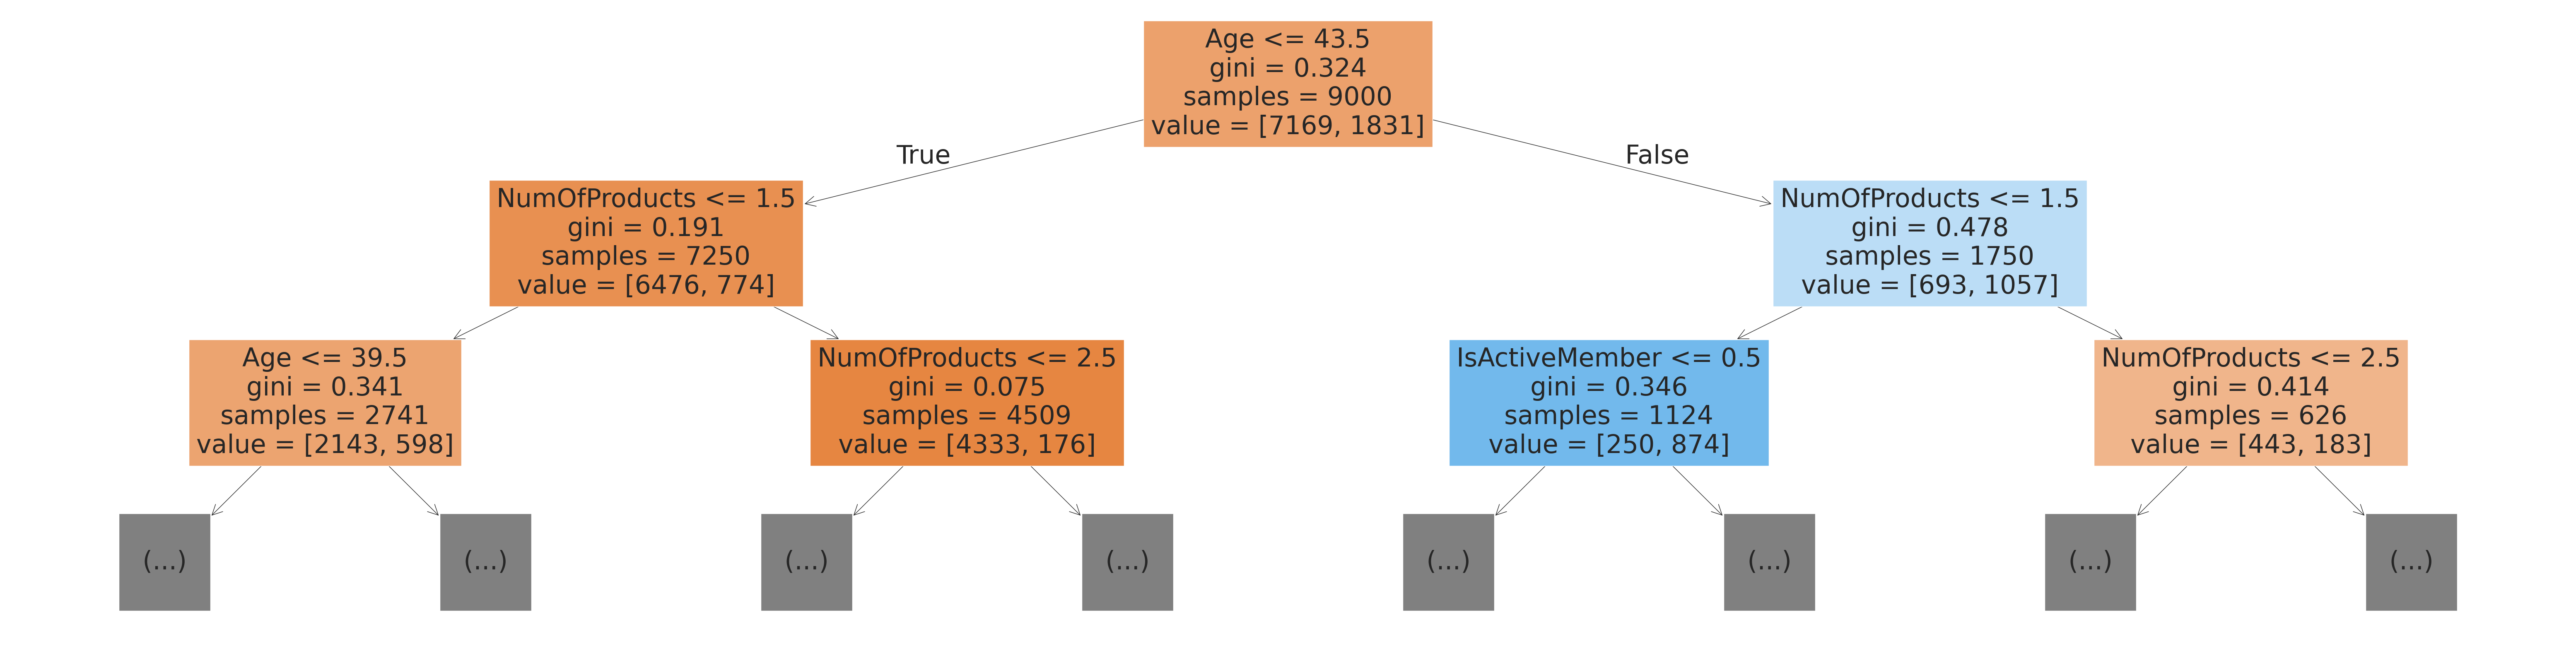

In [31]:
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, max_depth=2, filled=True)

In [32]:
tree_text = export_text(model, max_depth=2, feature_names=list(X_train.columns))
print(tree_text[:5000])

|--- Age <= 43.50
|   |--- NumOfProducts <= 1.50
|   |   |--- Age <= 39.50
|   |   |   |--- truncated branch of depth 18
|   |   |--- Age >  39.50
|   |   |   |--- truncated branch of depth 18
|   |--- NumOfProducts >  1.50
|   |   |--- NumOfProducts <= 2.50
|   |   |   |--- truncated branch of depth 18
|   |   |--- NumOfProducts >  2.50
|   |   |   |--- truncated branch of depth 7
|--- Age >  43.50
|   |--- NumOfProducts <= 1.50
|   |   |--- IsActiveMember <= 0.50
|   |   |   |--- truncated branch of depth 15
|   |   |--- IsActiveMember >  0.50
|   |   |   |--- truncated branch of depth 15
|   |--- NumOfProducts >  1.50
|   |   |--- NumOfProducts <= 2.50
|   |   |   |--- truncated branch of depth 18
|   |   |--- NumOfProducts >  2.50
|   |   |   |--- class: 1.0



Ми маємо три найвпливовіших ознаки:Age, NumOfProducts та IsActiveMember.

In [33]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [34]:
importance_df.head(10)

,feature,importance
1,Age,0.342819
4,NumOfProducts,0.172299
7,EstimatedSalary,0.128627
0,CreditScore,0.127141
3,Balance,0.078375
2,Tenure,0.055775
6,IsActiveMember,0.033898
9,Geography_Germany,0.018366
11,Gender_Female,0.009694
5,HasCrCard,0.009121


Цікаво, бо на дереві з глибиною два я виділила ознаку IsActiveMember як одну з трьох найважливіших, але тут видно що вона аж на 7 місці.

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [35]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)

In [36]:
model.fit(X_train, train_targets)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [37]:
model.score(X_train, train_targets)

0.881

In [38]:
model.score(X_val, val_targets)

0.8753333333333333

In [39]:
model.classes_

array([0., 1.])

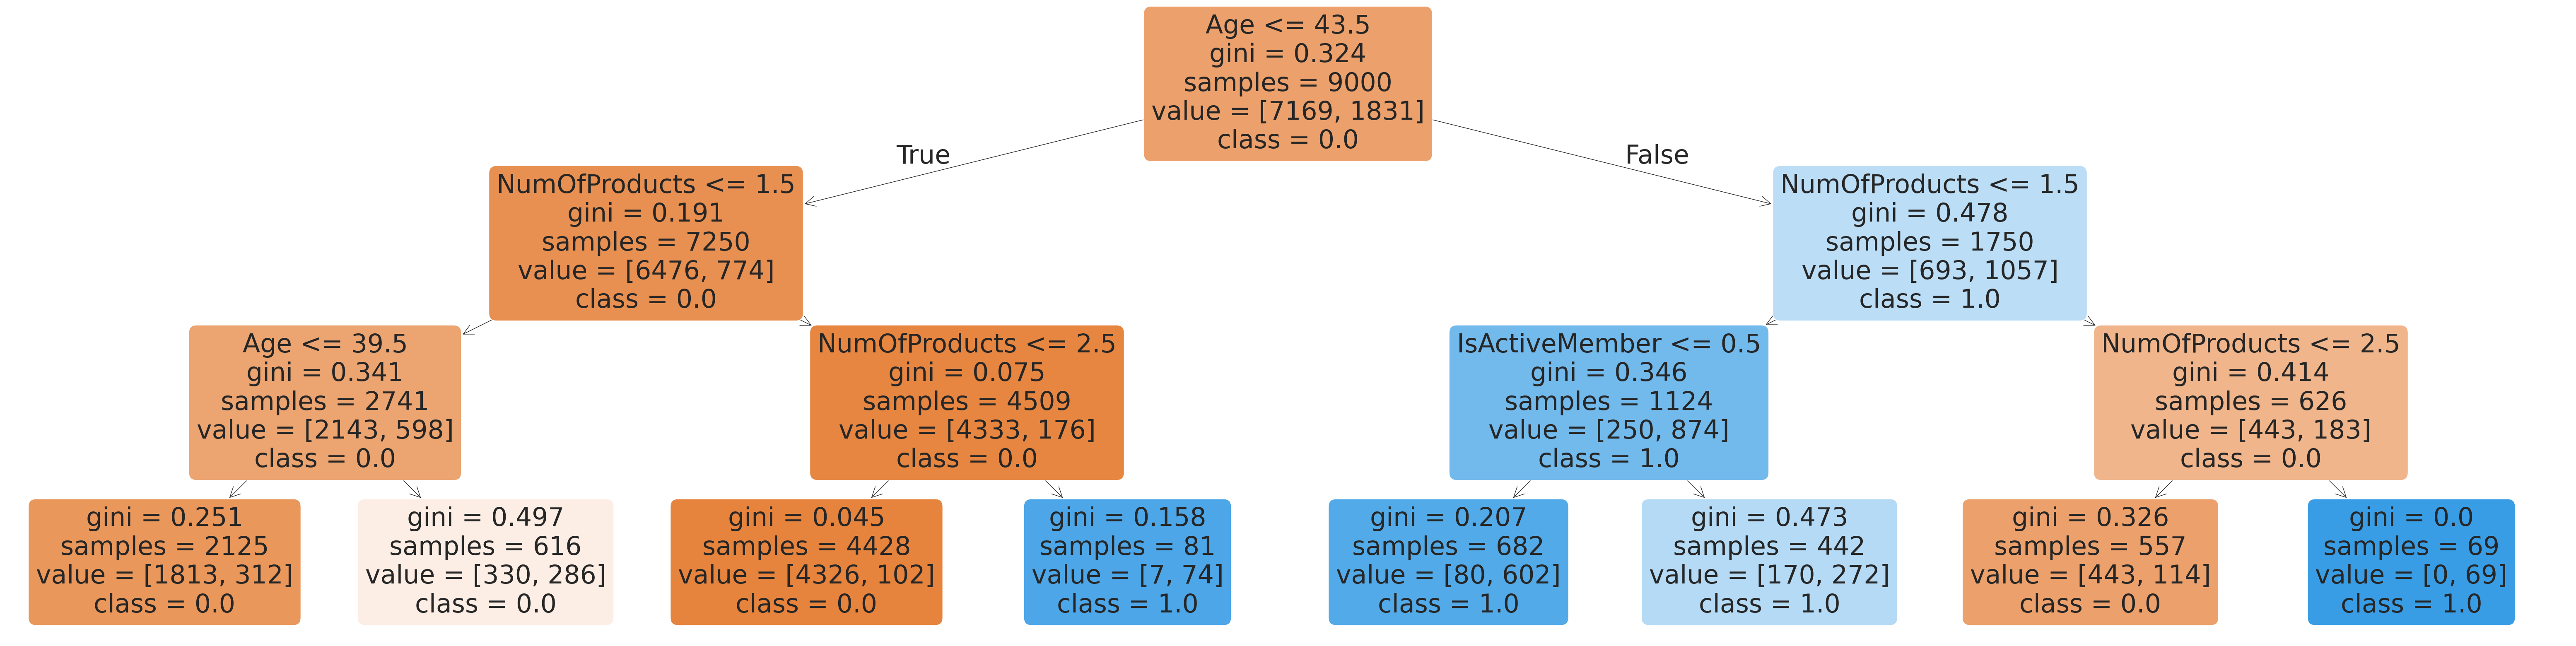

In [41]:
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, filled=True, rounded=True, class_names=[str(c) for c in model.classes_]);

In [43]:
print(export_text(model, feature_names=list(X_train.columns)))

|--- Age <= 43.50
|   |--- NumOfProducts <= 1.50
|   |   |--- Age <= 39.50
|   |   |   |--- class: 0.0
|   |   |--- Age >  39.50
|   |   |   |--- class: 0.0
|   |--- NumOfProducts >  1.50
|   |   |--- NumOfProducts <= 2.50
|   |   |   |--- class: 0.0
|   |   |--- NumOfProducts >  2.50
|   |   |   |--- class: 1.0
|--- Age >  43.50
|   |--- NumOfProducts <= 1.50
|   |   |--- IsActiveMember <= 0.50
|   |   |   |--- class: 1.0
|   |   |--- IsActiveMember >  0.50
|   |   |   |--- class: 1.0
|   |--- NumOfProducts >  1.50
|   |   |--- NumOfProducts <= 2.50
|   |   |   |--- class: 0.0
|   |   |--- NumOfProducts >  2.50
|   |   |   |--- class: 1.0



In [51]:
model = DecisionTreeClassifier(max_leaf_nodes=128, random_state=42)

In [52]:
model.fit(X_train, train_targets)

DecisionTreeClassifier(max_leaf_nodes=128, random_state=42)

In [53]:
model.score(X_train, train_targets)

0.9246666666666666

In [54]:
model.score(X_val, val_targets)

0.8913333333333333

In [55]:
model.tree_.max_depth

13

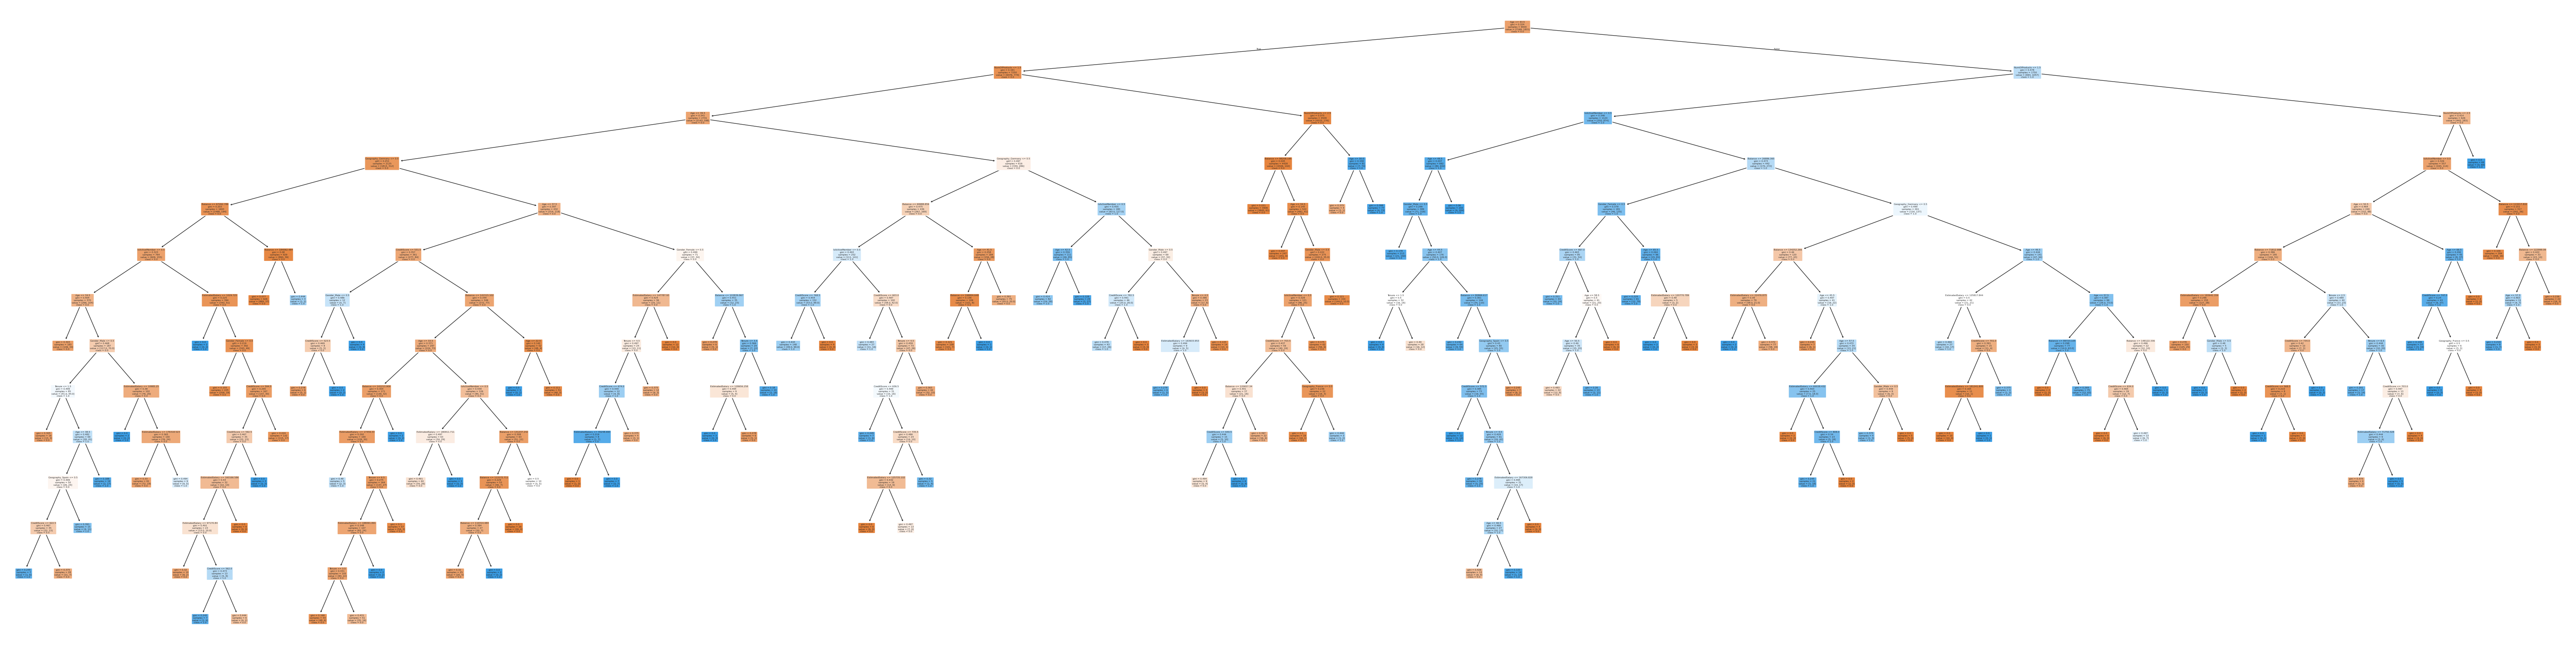

In [57]:
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, filled=True, rounded=True, class_names=[str(c) for c in model.classes_]);

In [58]:
model_text = export_text(model, feature_names=list(X_train.columns))
print(model_text[:3000])

|--- Age <= 43.50
|   |--- NumOfProducts <= 1.50
|   |   |--- Age <= 39.50
|   |   |   |--- Geography_Germany <= 0.50
|   |   |   |   |--- Balance <= 67262.79
|   |   |   |   |   |--- IsActiveMember <= 0.50
|   |   |   |   |   |   |--- Age <= 34.50
|   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |--- Age >  34.50
|   |   |   |   |   |   |   |--- Gender_Male <= 0.50
|   |   |   |   |   |   |   |   |--- Tenure <= 1.50
|   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |--- Tenure >  1.50
|   |   |   |   |   |   |   |   |   |--- Age <= 38.50
|   |   |   |   |   |   |   |   |   |   |--- Geography_Spain <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |   |--- Geography_Spain >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |   |   |--- Age >  38.50
|   |   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |

In [59]:
base_tree = DecisionTreeClassifier(random_state=42)
base_tree.fit(X_train, train_targets)

train_auc = roc_auc_score(train_targets, base_tree.predict_proba(X_train)[:,1])
val_auc = roc_auc_score(val_targets, base_tree.predict_proba(X_val)[:,1])

print("Base model")
print("Train AUC:", train_auc)
print("Val AUC:", val_auc)

Base model
Train AUC: 1.0
Val AUC: 0.7772359539323371


In [60]:
results = []

for depth in [2, 3, 4, 5, 6, 8, 10, None]:
    for leaves in [5, 10, 20, 30, 50, None]:

        tree = DecisionTreeClassifier(
            random_state=42,
            max_depth=depth,
            max_leaf_nodes=leaves
        )

        tree.fit(X_train, train_targets)

        train_auc = roc_auc_score(
            train_targets,
            tree.predict_proba(X_train)[:,1]
        )

        val_auc = roc_auc_score(
            val_targets,
            tree.predict_proba(X_val)[:,1]
        )

        results.append({
            "max_depth": depth,
            "max_leaf_nodes": leaves,
            "train_auc": train_auc,
            "val_auc": val_auc
        })

In [67]:

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("val_auc", ascending=False)

results_df.head(10).round(2)

,max_depth,max_leaf_nodes,train_auc,val_auc
33,8.0,30.0,0.93,0.92
34,8.0,50.0,0.93,0.92
46,NaN,50.0,0.93,0.92
40,10.0,50.0,0.93,0.92
27,6.0,30.0,0.93,0.92
22,5.0,50.0,0.93,0.92
21,5.0,30.0,0.93,0.92
39,10.0,30.0,0.92,0.92
45,NaN,30.0,0.92,0.92
23,5.0,NaN,0.93,0.92


**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [46]:
def max_depth_error(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train, train_targets)
    train_error = 1 - model.score(X_train, train_targets)
    val_error = 1 - model.score(X_val, val_targets)
    return {'Max Depth': md, 'Training Error': train_error, 'Validation Error': val_error}

In [47]:
%%time
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 21)])

CPU times: user 889 ms, sys: 0 ns, total: 889 ms
Wall time: 892 ms


In [48]:
errors_df.style.background_gradient(subset='Validation Error', cmap='Blues_r')

,Max Depth,Training Error,Validation Error
0,1,0.163000,0.168333
1,2,0.134111,0.140667
2,3,0.119000,0.124667
3,4,0.112778,0.119667
4,5,0.101778,0.103667
5,6,0.095778,0.108000
6,7,0.088778,0.109000
7,8,0.079556,0.119333
8,9,0.068889,0.117333
9,10,0.058667,0.120333


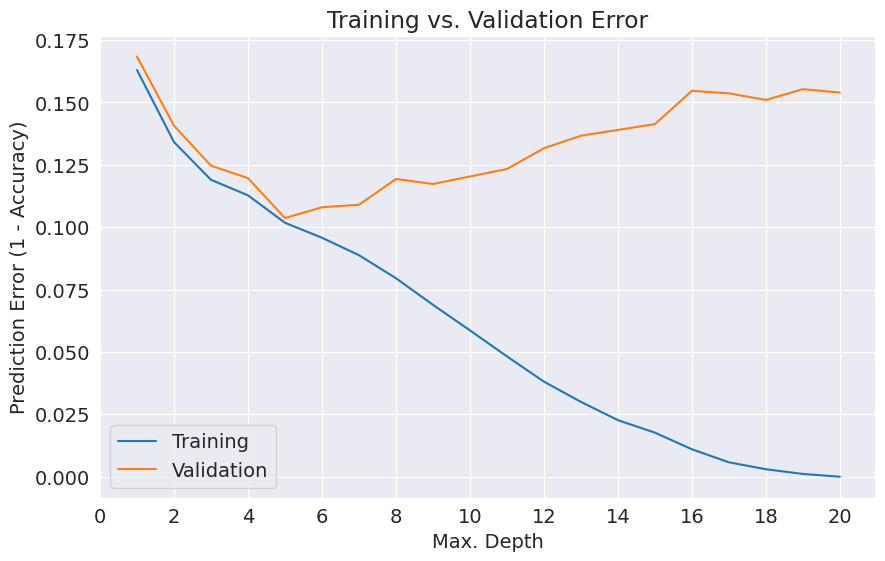

In [49]:
plt.figure()
plt.plot(errors_df['Max Depth'], errors_df['Training Error'])
plt.plot(errors_df['Max Depth'], errors_df['Validation Error'])
plt.title('Training vs. Validation Error')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation']);

In [65]:
model = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, train_targets)
model.score(X_val, val_targets)

0.8963333333333333

In [74]:
model = DecisionTreeClassifier(random_state=42)
path = model.cost_complexity_pruning_path(X_train, train_targets)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

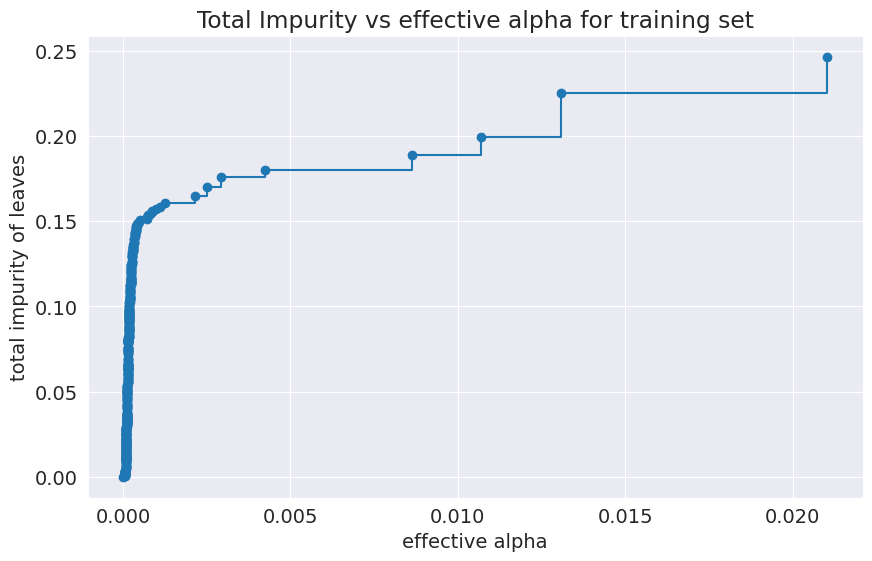

In [75]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set");

In [76]:
len(ccp_alphas)

406

In [77]:
models = []
for ccp_alpha in ccp_alphas[-10:]:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    model.fit(X_train, train_targets)
    models.append(model)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        models[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.07745608769689236


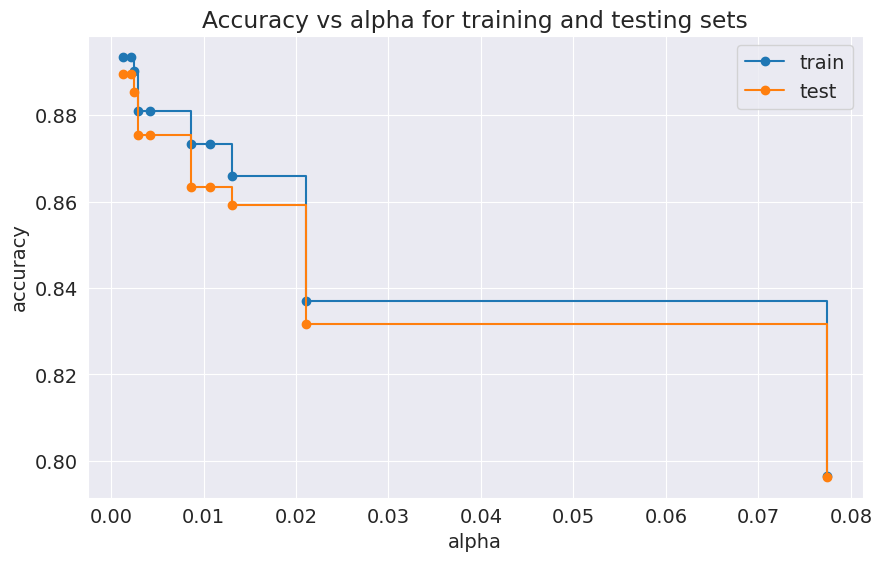

In [78]:
train_scores = [model.score(X_train, train_targets) for model in models]
val_scores = [model.score(X_val, val_targets) for model in models]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas[-10:], train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas[-10:], val_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [79]:
model = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alphas[-20])
model.fit(X_train, train_targets)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0005018395252837978),
                       random_state=42)

In [80]:
model.tree_.max_depth

8

In [81]:
model.score(X_train, train_targets)

0.9006666666666666

In [82]:
model.score(X_val, val_targets)

0.898

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [97]:

best_depth = 5

X_full = pd.concat([X_train, X_val], axis=0)
y_full = pd.concat([train_targets, val_targets], axis=0)

final_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_tree.fit(X_full, y_full)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [99]:
test_df = pd.read_csv('./bank-customer-churn-prediction-dlu-course-c-4/test.csv')

In [100]:
X_test_kaggle = preprocess_new_data(
    test_df,
    input_cols=data["input_cols"],
    scaler=data["scaler"],
    encoder=data["encoder"],
    scaler_numeric=False
)

In [101]:
test_probs = final_tree.predict_proba(X_test_kaggle)[:, 1]

In [103]:
sample_submission_df = pd.read_csv('./bank-customer-churn-prediction-dlu-course-c-4/sample_submission.csv')
sample_submission_df['Exited'] = test_probs
print(sample_submission_df.head())
sample_submission_df.to_csv('submission_log_reg.csv', index=False)

      id    Exited
0  15000  0.203762
1  15001  0.011519
2  15002  0.040747
3  15003  0.620370
4  15004  0.040747
